# 🌳 Classification and Regression Trees

### What is CART?
CART stands for **Classification And Regression Trees**.  
It’s a supervised learning algorithm that builds a **decision tree** to predict outcomes.

- **Classification Trees** → predict categories (e.g., species of flower).  
- **Regression Trees** → predict continuous values (e.g., house prices).  


### How Do Decision Trees Work?
- Start with all the data at the root.  
- Ask a **yes/no question** about one feature (e.g., "Is petal length < 2.5 cm?").  
- Split the data into two groups.  
- Repeat the process recursively until:
  - The nodes are "pure enough" (mostly one class), or  
  - A stopping rule is reached (max depth, min samples, etc.). 

## Decision Trees: Overfitting

Decision trees tend to grow very deep if built without setting stopping criteria in advance.  
A very complex tree can perfectly separate the training data, but it also risks capturing the noise in the dataset.

This leads to:

- **Overfitting**: excellent performance on the training set but poor performance on new data.  
- **High variance**: small variations in the data can produce very different trees.  

In practice, a tree without limitations is often too *specialized* and does not generalize well.

## Decision Trees: Pruning Techniques

To counteract overfitting, there are two main pruning strategies:

- **Early stopping (pre-pruning):**  
  The size of the tree is limited in advance, for example by setting:  
  - a maximum depth (`max_depth`),  
  - a minimum number of samples required to split a node (`min_samples_split`),  
  - or a minimum number of samples required at a leaf node (`min_samples_leaf`).

- **Cost complexity pruning (post-pruning):**  
  A very large tree is first built, and then simplified by removing the less useful branches.  
  The pruning criterion balances the complexity of the tree with its performance.

 


### Splitting Criteria
Decision trees decide *where to split* using metrics that measure **impurity** (how mixed the classes are) or **error**.

### For Classification:
- **Gini Impurity**:  

### For Regression:
- **Mean Squared Error (MSE)**:  

### Pros and Cons of Decision Trees
✅ **Pros**:
- Easy to understand and visualize.  
- Handles both numerical and categorical data.  
- No need for feature scaling.  
- Can capture non‑linear relationships.  

❌ **Cons**:
- Prone to **overfitting** (trees can grow too deep).  
- Small changes in data can lead to very different trees.  
- Not as accurate as ensemble methods (Random Forests, Gradient Boosting).  

### When to Use Decision Trees
- When interpretability is important.  
- As a **baseline model** before trying more complex methods.  
- As building blocks for **ensemble methods** (Random Forest, XGBoost).  


## Implementation Of a Classification  Decision Tree

**Data Preparation**


In [37]:
import pandas as pd

df = pd.read_csv("iris.csv")

x = df.drop(columns=["variety"])
y = df["variety"]

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

### Training The Model 

In [38]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(criterion="gini", max_depth=2, random_state=42)
decision_tree_model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Prediction And Evaluation 

In [39]:
from sklearn.metrics import classification_report

y_pred = decision_tree_model.predict(x_test)

print(classification_report(y_test, y_pred))  

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### VIewing THe TRee

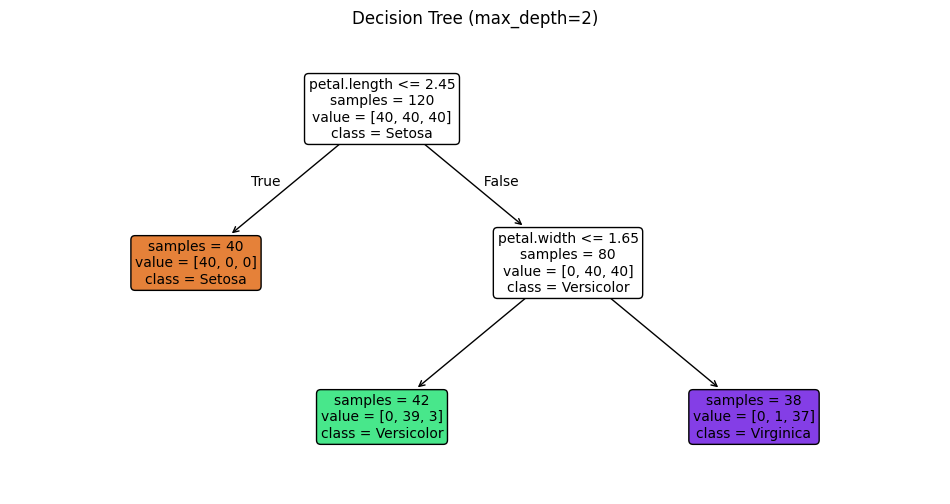

In [40]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize the decision tree
plt.figure(figsize=(12, 6))
plot_tree(
    decision_tree_model,
    feature_names=x_train.columns,   
    class_names=[str(c) for c in decision_tree_model.classes_],
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=10
)
plt.title("Decision Tree (max_depth=2)")
plt.show()


### Implementation of a Regression Tree:    

In [ ]:
df_2 = pd.read_csv("usa_houses.csv")

df_2 = df_2[(df_2["price"] < 2000000) & (df_2["sqft_living"] >= 1000)]

x_2 = df_2[["bedrooms", "bathrooms", "sqft_living",  "floors"]]
y_2 = df_2["price"]

x_train_2, x_test_2, y_train_2, y_test_2 = train_test_split(x_2, y_2, test_size=0.2, random_state=42)

### Model Training 

In [42]:
from sklearn.tree import DecisionTreeRegressor

regression_tree_model = DecisionTreeRegressor(criterion="squared_error", max_depth=3, random_state=42)
regression_tree_model.fit(x_train_2, y_train_2)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Model Evaluation

In [43]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_2 = regression_tree_model.predict(x_test_2)

mse = mean_squared_error(y_test_2, y_pred_2)
r2 = r2_score(y_test_2, y_pred_2)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")



Mean Squared Error: 46702039818.64
R² Score: 0.38
